# Time series forecasting 

In [42]:
 pip install statsforecast utilsforecast

Note: you may need to restart the kernel to use updated packages.


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import*

import warnings
warnings.filterwarnings("ignore")

In [44]:
df  = pd.read_csv("daily_sales_french_bakery.csv", parse_dates=['ds'])
df = df.groupby('unique_id').filter(lambda x: len(x)>= 28)
df = df.drop(["unit_price"] , axis =1)
df.head()

,unique_id,ds,y
0,12 MACARON,2022-07-13,10.0
1,12 MACARON,2022-07-14,0.0
2,12 MACARON,2022-07-15,0.0
3,12 MACARON,2022-07-16,10.0
4,12 MACARON,2022-07-17,30.0


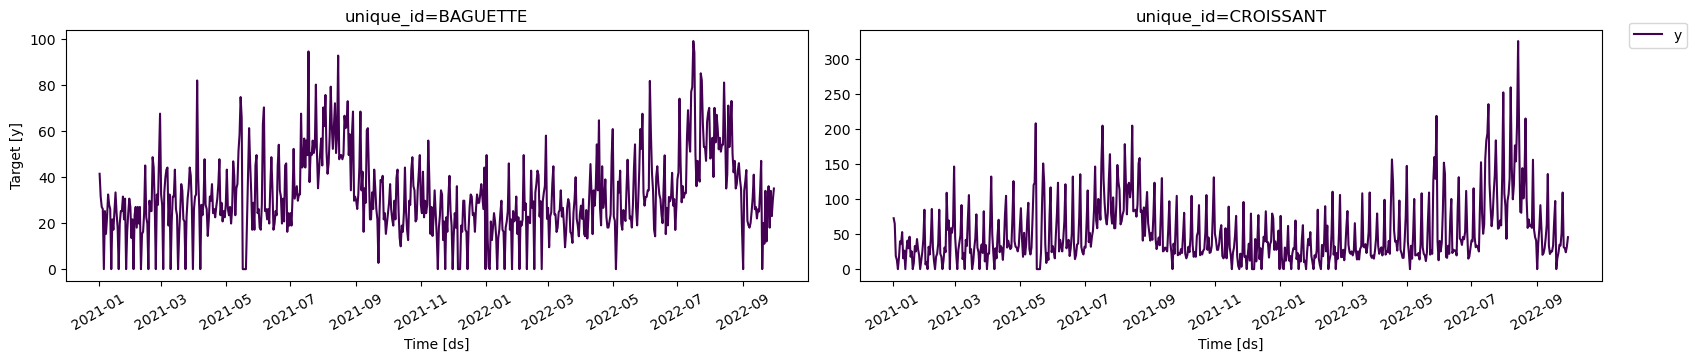

In [45]:
plot_series(df = df, ids=["BAGUETTE","CROISSANT"],palette="viridis")

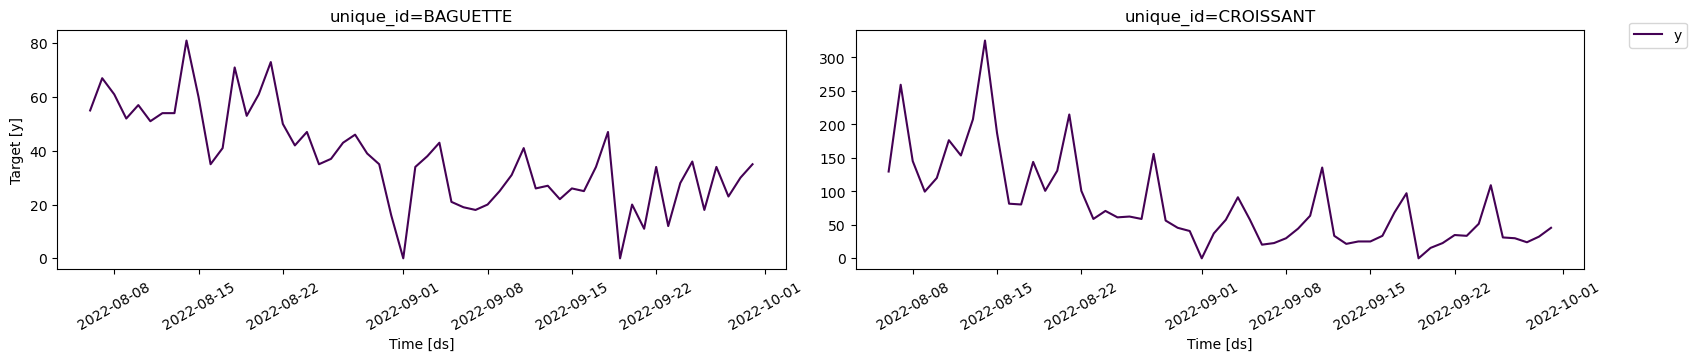

In [46]:
plot_series(df = df, ids=["BAGUETTE","CROISSANT"],max_insample_length=56, palette="viridis") # plotting the last 56 data staampa


# BaseLine model

In [47]:
from statsforecast import StatsForecast
from statsforecast.models  import Naive , HistoricAverage , WindowAverage , SeasonalNaive

In [48]:
horizon = 7 # predict it for new 7 days
models = [
    Naive(),# will forecast teh last time known time step
    HistoricAverage(), # this will take the average of the entire history and use that to forecast
    WindowAverage(window_size=7), # how many time steps do you want to take into account calc to the avg and then forecast teh avg
    SeasonalNaive(season_length=7)# how long is the season , in this data it loks for 7 days   
]
sf= StatsForecast(models=models , freq='D')# D- daily , freq strings similar to pandas
sf.fit(df=df)
preds = sf.predict(h=horizon)


In [49]:
preds.head()

,unique_id,ds,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,12 MACARON,2022-09-29,10.0,8.974359,2.857143,0.0
1,12 MACARON,2022-09-30,10.0,8.974359,2.857143,0.0
2,12 MACARON,2022-10-01,10.0,8.974359,2.857143,10.0
3,12 MACARON,2022-10-02,10.0,8.974359,2.857143,0.0
4,12 MACARON,2022-10-03,10.0,8.974359,2.857143,0.0


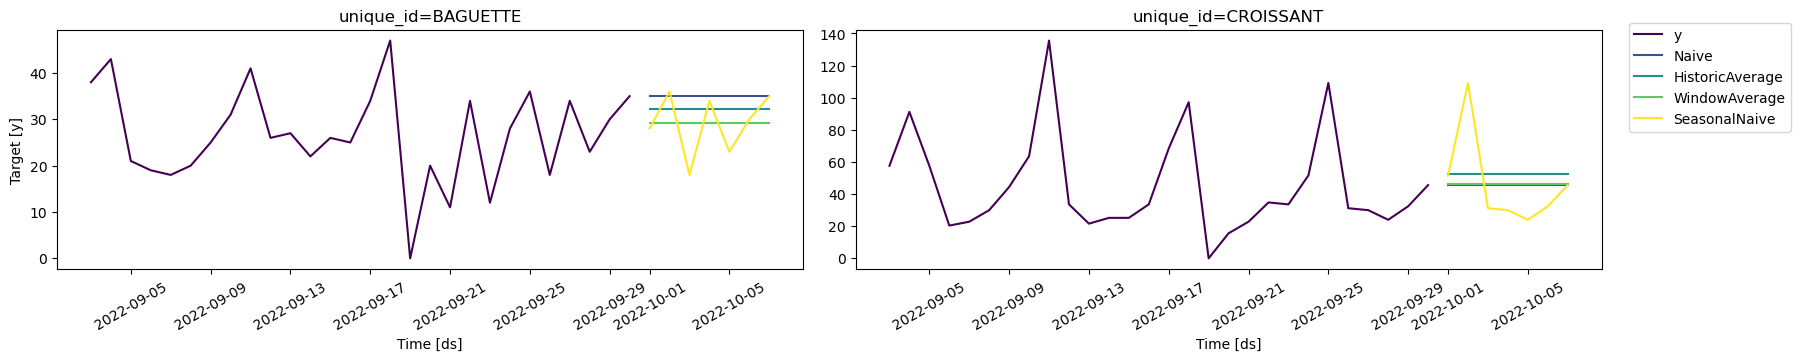

In [50]:
# plotting the predictions
plot_series(
    df=df,
    forecasts_df = preds,
    ids=["BAGUETTE","CROISSANT"],
    max_insample_length=28,
    palette="viridis")
    
    

In [51]:
#split
test = df.groupby("unique_id").tail(7)
train = df.drop(test.index).reset_index(drop=True)

In [52]:
sf.fit(df=train)
preds = sf.predict(h=horizon)
eval_df = pd.merge(test, preds, 'left',['ds', 'unique_id']) # merging , left merge on the basis of 'ds' and 'unique_id'

In [53]:
evaluation = evaluate(
    eval_df,
    metrics=[mae], # mean absolute error
)
evaluation.head()

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,12 MACARON,mae,2.857143,6.961771,3.469388,4.285714
1,BAGUETTE,mae,17.142857,5.455193,7.877551,12.571429
2,BAGUETTE APERO,mae,0.000000,0.537572,0.642857,0.642857
3,BAGUETTE GRAINE,mae,9.800000,4.612271,2.942857,0.200000
4,BANETTE,mae,1.314286,5.421984,6.008163,7.885714


In [54]:
evaluation = evaluation.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
evaluation.head()

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,6.107556,5.228439,5.011663,4.613636


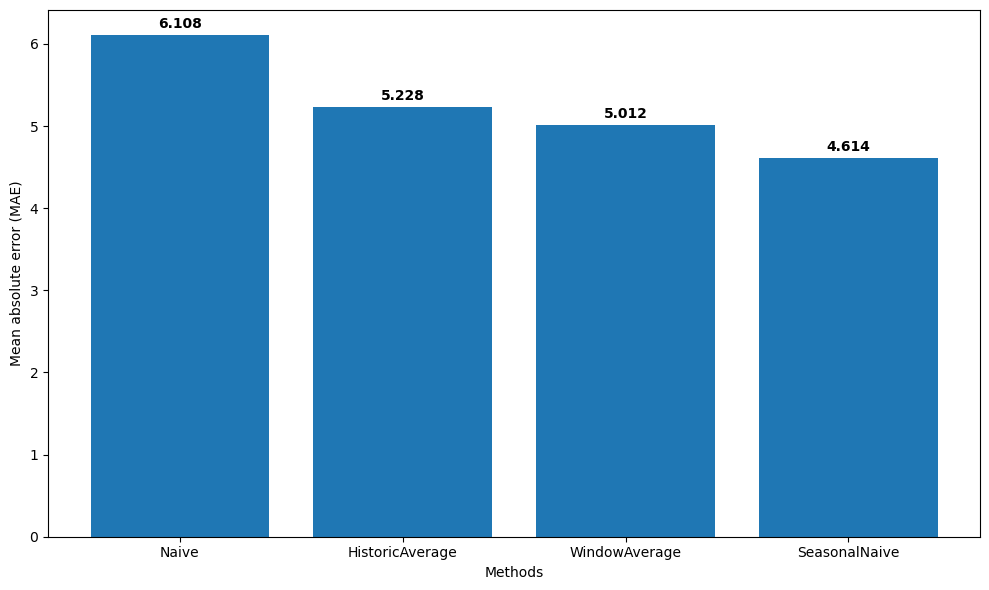

In [55]:
methods = evaluation.columns[1:].tolist()  
values = evaluation.iloc[0, 1:].tolist() 

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, values)

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.tight_layout()

plt.show()

# AutoARIMA model

In [56]:
from statsforecast.models import AutoARIMA

In [57]:
unique_ids  = ["BAGUETTE" ,"CROISSANT"]
small_train= train[train["unique_id"].isin(unique_ids)]
small_test= test[test["unique_id"].isin(unique_ids)]

models = [
    AutoARIMA(seasonal=False , alias ="ARIMA"),
    AutoARIMA(season_length=7 , alias ="SARIMA")
]

sf = StatsForecast(models=models , freq = "D")
sf.fit(df = small_train)
arima_preds = sf.predict(h=horizon)
arima_eval_df = pd.merge(arima_preds , eval_df, 'inner',['ds','unique_id'])
arima_eval =evaluate(
    arima_eval_df,
    metrics =[mae],
)
arima_eval

,unique_id,metric,ARIMA,SARIMA,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,BAGUETTE,mae,9.353153,7.449083,17.142857,5.455193,7.877551,12.571429
1,CROISSANT,mae,14.565396,10.359143,17.485714,22.618934,18.244898,12.857143


In [58]:
arima_eval = arima_eval.drop(['unique_id'],axis=1).groupby('metric').mean().reset_index()
arima_eval

,metric,ARIMA,SARIMA,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,11.959274,8.904113,17.314286,14.037063,13.061224,12.714286


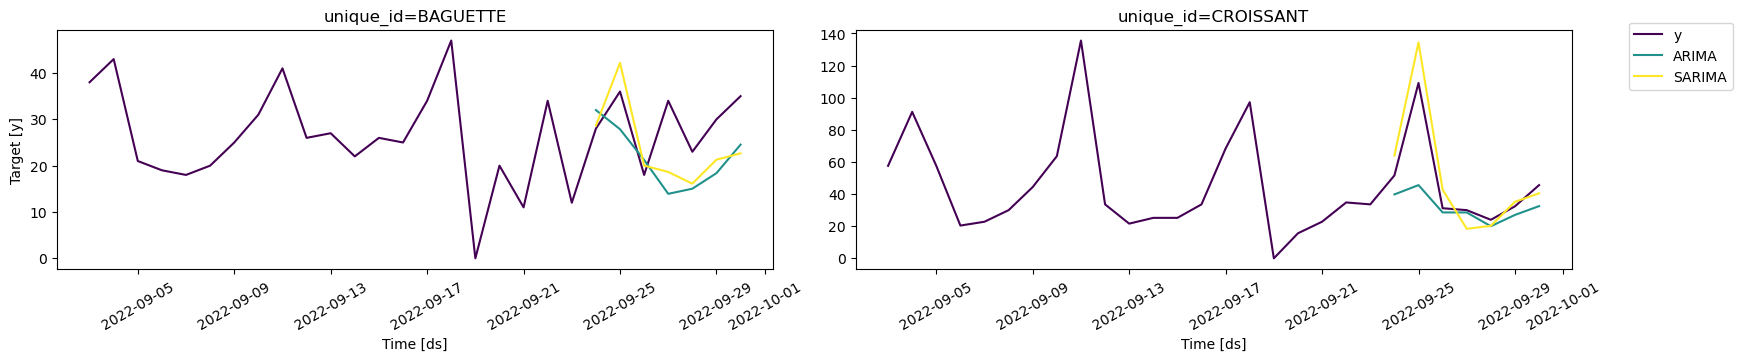

In [59]:
# plotting the predictions
plot_series(
    df=df,
    forecasts_df = arima_preds,
    ids=["BAGUETTE","CROISSANT"],
    max_insample_length=28,
    palette="viridis")

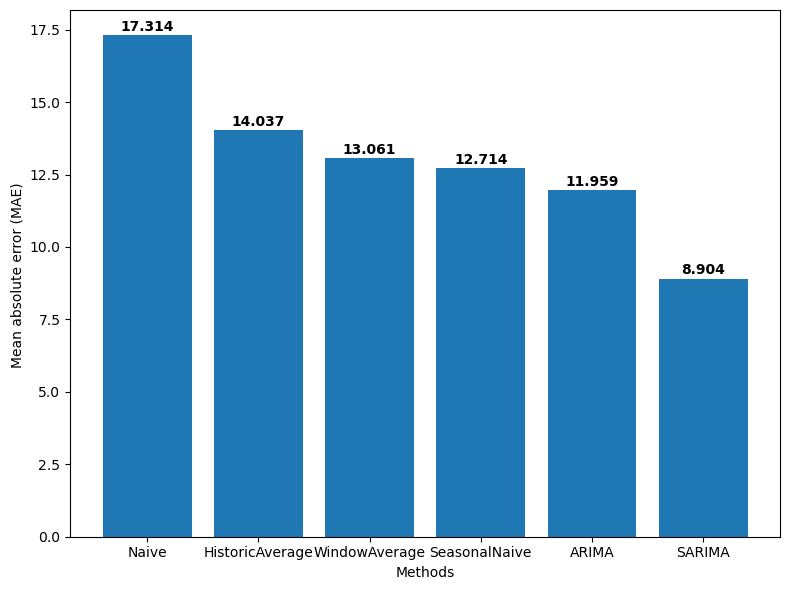

In [60]:
methods = arima_eval.columns[1:].tolist()  
values = arima_eval.iloc[0, 1:].tolist() 

sorted_data = sorted(zip(methods, values), key=lambda x: x[1], reverse=True)
methods_sorted, values_sorted = zip(*sorted_data)

plt. figure(figsize=(8, 6))
bars = plt.bar (methods_sorted, values_sorted)

for bar, value in zip(bars, values_sorted) :
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
        f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel( 'Methods')
plt.ylabel( 'Mean absolute error (MAE) ')
plt. tight_layout()
plt.show()
# as we are only running on last 7 time stamp , SARIMA is good , but must run more than that


# Cross_validation

In [61]:
# we dont need train-test split as we will be using diff windows (dont need train test split)

In [62]:
small_df = df[df["unique_id"].isin(unique_ids)]
models = [
    SeasonalNaive(season_length=7),
    AutoARIMA(seasonal=False, alias='ARIMA'),
    AutoARIMA(season_length=7,alias='SARIMA'),
]
sf = StatsForecast(models=models, freq="D")
cv_df = sf.cross_validation(
    h=horizon,
    df=small_df,
    n_windows = 8,
    step_size = horizon,#if less then may overlap
    refit= True # might be little slow due to refitting parameters everytime but might give better results too
)

cv_df.head() # kaafi time lega 

,unique_id,ds,cutoff,y,SeasonalNaive,ARIMA,SARIMA
0,BAGUETTE,2022-08-06,2022-08-05,55.0,68.0,71.355199,71.584715
1,BAGUETTE,2022-08-07,2022-08-05,67.0,70.0,70.337983,78.458884
2,BAGUETTE,2022-08-08,2022-08-05,61.0,48.0,61.195008,57.001733
3,BAGUETTE,2022-08-09,2022-08-05,52.0,49.0,52.649014,49.401146
4,BAGUETTE,2022-08-10,2022-08-05,57.0,57.0,47.785876,49.725280


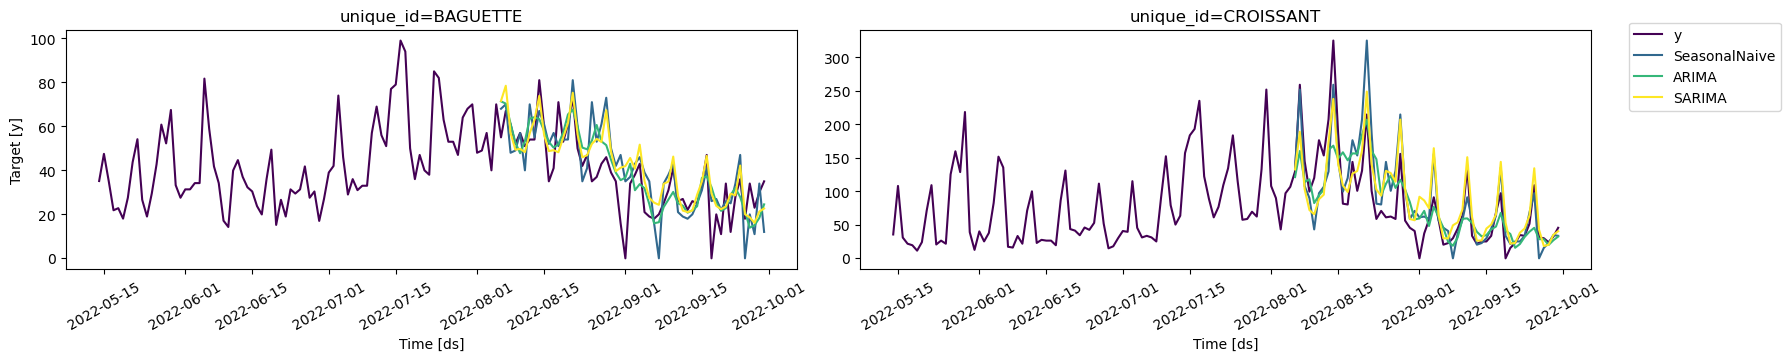

In [63]:
plot_series(
    df=small_df,
    forecasts_df = cv_df.drop(["y","cutoff"],axis=1),
    ids=["BAGUETTE","CROISSANT"],
    max_insample_length=140,
    palette="viridis")

In [64]:
cv_eval = evaluate(
    cv_df.drop(["cutoff"],axis =1),
    metrics=[mae],
)
cs_eval = cv_eval.drop(["unique_id"],axis=1).groupby("metric").mean().reset_index()
cv_eval

,unique_id,metric,SeasonalNaive,ARIMA,SARIMA
0,BAGUETTE,mae,11.035714,9.028331,8.787206
1,CROISSANT,mae,31.200000,33.313529,29.775383


In [69]:
methods = cv_eval.columns[1:].tolist()
#values = cv_eval.iloc[0, 1:].tolist()
values = cv_eval.iloc[0, 1:].tolist()

sorted_data = sorted(zip(methods, values), key=lambda x: x[1], reverse=True)
methods_sorted, values_sorted = zip(*sorted_data)

plt.figure(figsize=(10, 6))
bars = plt.bar(methods_sorted, values_sorted)

for bar, value in zip(bars, values_sorted):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt. tight_layout()

plt.show()

UFuncTypeError: ufunc 'greater' did not contain a loop with signature matching types (<class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.StrDType'>) -> None

In [70]:
#Forecasting with exoenous features 
# exogenous features are external variables that are not part of the time series itself

In [72]:
#rereading the dataset
df = pd.read_csv("daily_sales_french_bakery.csv",parse_dates=["ds"])
df = df.groupby('unique_id').filter(lambda x: len(x) >= 28)
df.head()
    

,unique_id,ds,y,unit_price
0,12 MACARON,2022-07-13,10.0,10.0
1,12 MACARON,2022-07-14,0.0,10.0
2,12 MACARON,2022-07-15,0.0,10.0
3,12 MACARON,2022-07-16,10.0,10.0
4,12 MACARON,2022-07-17,30.0,10.0


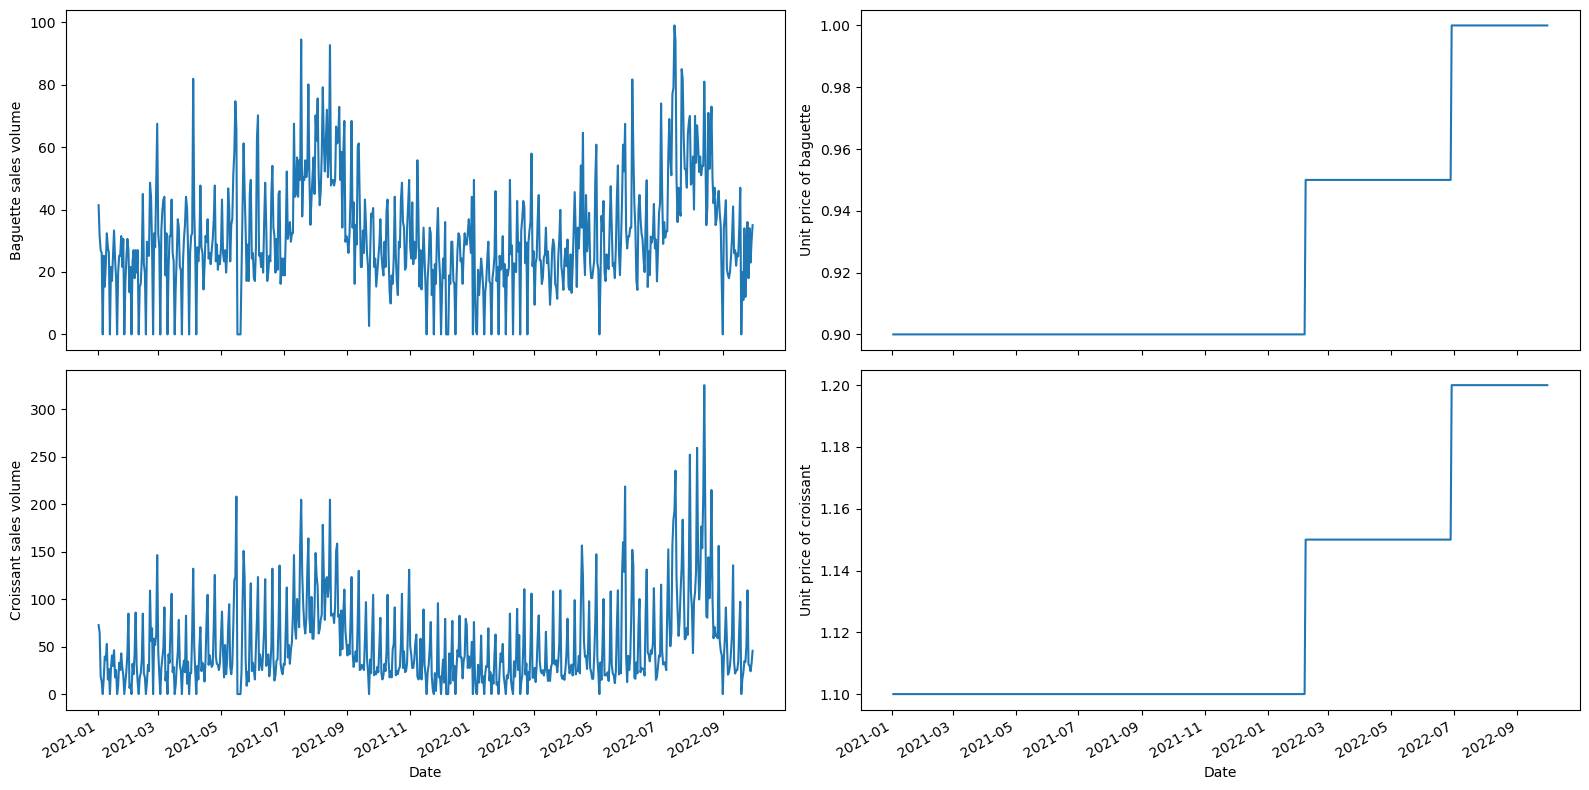

In [73]:
baguette_plot_df = df[df["unique_id"] == "BAGUETTE"]
croissant_plot_df = df[df["unique_id"] == "CROISSANT"]

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(16,8))

ax1.plot(baguette_plot_df["ds"], baguette_plot_df["y"])
ax1.set_xlabel("Date")
ax1.set_ylabel("Baguette sales volume")

ax2.plot(baguette_plot_df["ds"], baguette_plot_df["unit_price"])
ax2.set_xlabel("Date")
ax2.set_ylabel("Unit price of baguette")

ax3.plot(croissant_plot_df["ds"], croissant_plot_df["y"])
ax3.set_xlabel("Date")
ax3.set_ylabel("Croissant sales volume")

ax4.plot(croissant_plot_df["ds"], croissant_plot_df["unit_price"])
ax4.set_xlabel("Date")
ax4.set_ylabel("Unit price of croissant")

fig.autofmt_xdate()
plt.tight_layout()

In [74]:
unique_ids = ["BAGUETTE", "CROISSANT"]
small_df = df[df["unique_id"].isin(unique_ids)]
test = small_df.groupby("unique_id").tail(7)
train = small_df.drop(test.index).reset_index(drop=True)

In [75]:
futr_exog_df = test.drop(["y"], axis=1)
futr_exog_df.head()

,unique_id,ds,unit_price
714,BAGUETTE,2022-09-24,1.0
715,BAGUETTE,2022-09-25,1.0
716,BAGUETTE,2022-09-26,1.0
717,BAGUETTE,2022-09-27,1.0
718,BAGUETTE,2022-09-28,1.0


In [76]:
# deifne model
models = [
    AutoARIMA(season_length=7, alias="SARIMA_exog")
]

sf = StatsForecast(models=models, freq="D")
sf.fit(df=train)
#
arima_exog_preds = sf.predict(h=7, X_df=futr_exog_df)

models = [
    AutoARIMA(season_length=7, alias="SARIMA")
]

sf = StatsForecast(models=models, freq="D")
sf.fit(df=train.drop(["unit_price"], axis=1))
arima_preds = sf.predict(h=horizon)

In [77]:
test_df = test.merge(arima_exog_preds, on=["unique_id", "ds"], how="left")\
              .merge(arima_preds, on=["unique_id", "ds"], how="left")
test_df

,unique_id,ds,y,unit_price,SARIMA_exog,SARIMA
0,BAGUETTE,2022-09-24,28.0,1.0,28.898765,28.657114
1,BAGUETTE,2022-09-25,36.0,1.0,42.513080,42.182373
2,BAGUETTE,2022-09-26,18.0,1.0,20.423741,20.013653
3,BAGUETTE,2022-09-27,34.0,1.0,19.066027,18.646490
4,BAGUETTE,2022-09-28,23.0,1.0,16.468688,16.114925
5,BAGUETTE,2022-09-29,30.0,1.0,21.656531,21.288018
6,BAGUETTE,2022-09-30,35.0,1.0,23.100990,22.660124
7,CROISSANT,2022-09-24,51.6,1.2,64.423354,64.011002
8,CROISSANT,2022-09-25,109.2,1.2,135.121789,134.488202
9,CROISSANT,2022-09-26,31.2,1.2,43.523106,42.735408


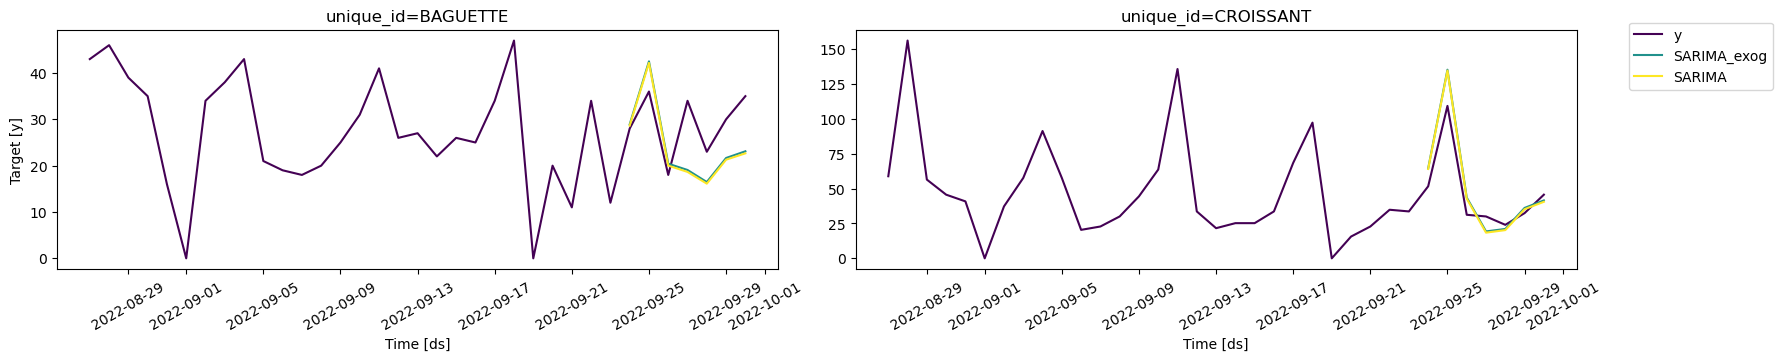

In [78]:
plot_series(
    df=train, 
    forecasts_df=test_df, 
    ids=["BAGUETTE", "CROISSANT"], 
    max_insample_length=28,
    models=["SARIMA_exog", "SARIMA"],
    palette="viridis"
)

In [ ]:
models = [
    AutoARIMA(season_length=7, alias="SARIMA_exog")
]

sf = StatsForecast(models=models, freq="D")
cv_exog_df = sf.cross_validation(
    h=horizon, # 7 days
    df=small_df,
    n_windows=8,
    step_size=7,
    refit=True
)

cv_exog_df.head()


# Create features from timestamp

In [ ]:
from functools import partial
from utilsforecast.feature_engineering import fourier, time_features, pipeline

In [ ]:
features = [
    partial(fourier, season_length=7, k=2),
    partial(time_features, features=["day", "week", "month"])
]

small_exog_df, futr_exog_df = pipeline(
    df=small_df,
    features=features,
    freq="D",
    h=horizon
)

In [ ]:
models = [
    AutoARIMA(season_length=7, alias="SARIMA_time_exog")
]

sf = StatsForecast(models=models, freq="D")
cv_time_exog_df = sf.cross_validation(
    h=horizon, # 7 days
    df=small_exog_df,
    n_windows=8,
    step_size=horizon,
    refit=True
)

cv_time_exog_eval = evaluate(
    cv_time_exog_df.drop(["cutoff"], axis=1),
    metrics=[mae],
)
cv_time_exog_eval = cv_time_exog_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
cv_time_exog_eval

In [ ]:
methods = ["ARIMA", "Seasonal naive", "SARIMA", "SARIMA_price_exog", "SARIMA_time_exog"] 
values = [21.229, 21.118, 19.281, 19.210, 19.533]

sorted_data = sorted(zip(methods, values), key=lambda x: x[1], reverse=True)
methods_sorted, values_sorted = zip(*sorted_data)

plt.figure(figsize=(10, 6))
bars = plt.bar(methods_sorted, values_sorted)

for bar, value in zip(bars, values_sorted):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.tight_layout()

plt.show()

In [ ]:
methods = ["ARIMA", "Seasonal naive", "SARIMA", "SARIMA_price_exog", "SARIMA_time_exog"] 
values = [21.229, 21.118, 19.281, 19.210, 19.533]

sorted_data = sorted(zip(methods, values), key=lambda x: x[1], reverse=True)
methods_sorted, values_sorted = zip(*sorted_data)

plt.figure(figsize=(10, 6))
bars = plt.bar(methods_sorted, values_sorted)

for bar, value in zip(bars, values_sorted):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.tight_layout()

plt.show()